In [1]:
from lpf_detchar import configuration, omicron

import matplotlib.pyplot as plt
# %matplotlib inline
from h5py import File
import numpy as np
import datetime

import jax
import jax.numpy as jnp
from scipy.signal import welch, get_window, detrend
# Source - https://stackoverflow.com/a/78139167
# Posted by JialeDu
# Retrieved 2026-09-21, License - CC BY-SA 4.0

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"



# jax.config.update("jax_enable_x64", True)

In [2]:
noisy_data = File("delta_g_x_L3_catalog_NoiseOnlySegments.h5", "r")



In [3]:
# [(x,y) for (x, y) in noisy_data["segment01"].attrs.items()]

In [4]:
# test = noisy_data.get("segment04")[:].T

In [5]:
# fig, ax = plt.subplots()

# ax.hist(test[int(len(test)/2):], histtype="step", label="first half")
# ax.hist(test[:int(len(test)/2)], histtype="step", label="second half")
# ax.legend()

In [6]:
# noisy_data.keys()

In [7]:
investigation_segment = "segment66"

segment_data = np.array(noisy_data.get(investigation_segment)).flatten()

In [8]:
start, end = noisy_data.get(investigation_segment).attrs["Timespan"].astype(str).split(";")
start = start.strip()
end = end.strip()

In [9]:
# end

In [10]:
# 

In [11]:
def get_gps_time_from_h5_formatted_time(h5_formatted_time):
    return datetime.datetime.strptime(h5_formatted_time, "%Y-%m-%d %H:%M:%S.%f %Z").timestamp()

def get_utc_from_gps_time(gpstime):
    return datetime.datetime.fromtimestamp(gpstime).strftime("%H:%M:%S")

In [12]:
start_unix = get_gps_time_from_h5_formatted_time(start)
end_unix = get_gps_time_from_h5_formatted_time(end)

In [13]:
target_time = "2017-02-20 15:20:00.000 UTC"
target_time_unix = get_gps_time_from_h5_formatted_time(target_time)

In [14]:
# 

In [15]:
total_duration = (end_unix - start_unix)
segment_duration = 800
number_segments = int(np.ceil(total_duration/segment_duration))

In [16]:
segment_sampling_frequency = (noisy_data[investigation_segment].attrs["fs"])[0]
start_index = (target_time_unix - start_unix) * segment_sampling_frequency
# start_index = 0

In [17]:
start_index

np.float64(6312000.0)

In [18]:
# start_unix

In [19]:
segment_start_times = np.linspace(0, total_duration - segment_duration, number_segments)
segment_start_times = np.round(segment_start_times)
segment_start_times

array([0.0000e+00, 8.0000e+02, 1.6000e+03, ..., 1.6032e+06, 1.6040e+06,
       1.6048e+06], shape=(2007,))

In [20]:
target_sampling_frequency = 10
omicron_configuration = configuration.OmicronConfiguration(
    start_time = int(target_time_unix),
    duration=segment_duration,
    target_sampling_frequency=target_sampling_frequency,
    starting_sampling_frequency=segment_sampling_frequency,
    maximum_quality_factor=20,
    minimum_quality_factor=4,
    maximum_energy_loss=0.03,
    maximum_characteristic_frequency = target_sampling_frequency / 4,
    minimum_characteristic_frequency = 4 / segment_duration,
    snr_threshold=5,
    maximum_triggers_per_segment=60000,
    cluster_distance_threshold=0.5,
    maximum_frequency=target_sampling_frequency / 4,
    minimum_frequency=4 / segment_duration
)
# time_domain_data = segment_data[int(start_index):int(start_index + segment_duration * segment_sampling_frequency)]
rng_key = jax.random.PRNGKey(61)
test_time_domain_data = jax.random.normal(key=rng_key, shape=int(segment_sampling_frequency*segment_duration))


In [21]:
resampled_time_domain_data = omicron.resample_timeseries(
    time_domain_data=test_time_domain_data,
    starting_sampling_frequency=omicron_configuration.starting_sampling_frequency,
    target_sampling_frequency=omicron_configuration.target_sampling_frequency,
    duration=omicron_configuration.duration
)
tukey_alpha = 0.2
whitened_time_domain_data, whitened_frequency_domain_data, frequency_mask, interpolated_psd= omicron.whiten_timeseries(resampled_time_domain_data, omicron_configuration.target_sampling_frequency, omicron_configuration.duration, minimum_frequency=omicron_configuration.minimum_frequency, maximum_frequency=omicron_configuration.maximum_frequency, tukey_alpha = omicron_configuration.tukey_alpha, number_welch_segments=omicron_configuration.number_welch_segments)

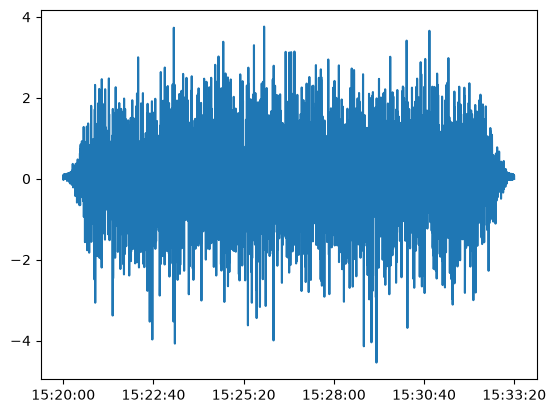

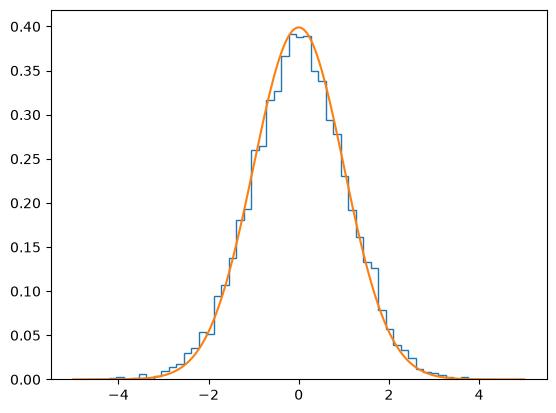

In [22]:
full_data_time_tick_indices = np.linspace(0, int(segment_duration * target_sampling_frequency), 6)
full_data_time_ticks = [get_utc_from_gps_time(float(x + start_index) / target_sampling_frequency + start_unix) for x in full_data_time_tick_indices]

fig, ax = plt.subplots()

ax.plot(whitened_time_domain_data)
ax.set_xticks(full_data_time_tick_indices,full_data_time_ticks)

from scipy.stats import norm

fig, ax = plt.subplots()

data_values = jnp.linspace(-5, 5, 1000)
ax.hist(whitened_time_domain_data[int(len(whitened_time_domain_data) * tukey_alpha / 2) : int(len(whitened_time_domain_data) * (1 - tukey_alpha / 2))], density=True, histtype="step", bins=50)
ax.plot(data_values, norm.pdf(data_values))

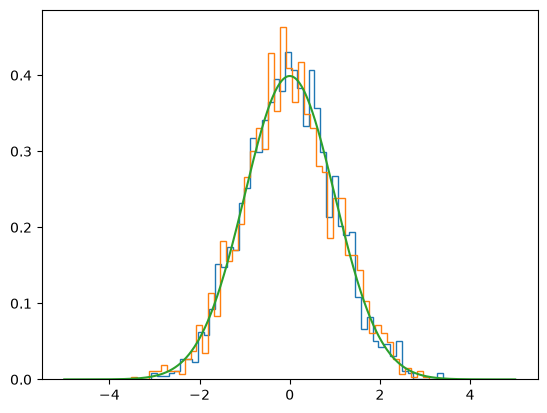

In [23]:
fig, ax = plt.subplots()

ax.hist(jnp.real(whitened_frequency_domain_data[frequency_mask]), histtype="step", density=True, bins=50)
ax.hist(jnp.imag(whitened_frequency_domain_data[frequency_mask]), histtype="step", density=True, bins=50)
ax.plot(data_values, norm.pdf(data_values))

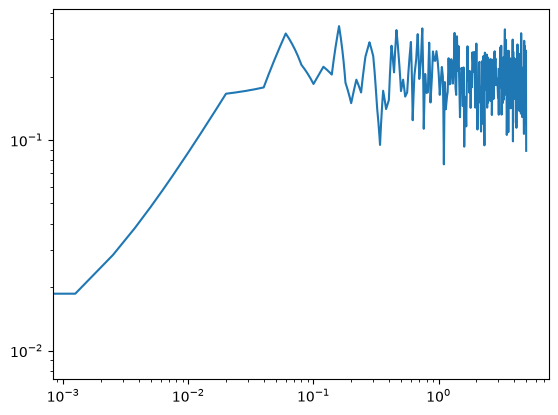

In [24]:
fig, ax = plt.subplots()

frequencies = np.linspace(0, target_sampling_frequency / 2, len(whitened_frequency_domain_data))
ax.loglog(frequencies, interpolated_psd)

In [25]:
quality_factors, characteristic_frequencies, times = omicron.get_tiles(
    energy_loss_max=omicron_configuration.maximum_energy_loss,
    quality_factor_max=omicron_configuration.maximum_quality_factor,
    quality_factor_min=omicron_configuration.minimum_quality_factor,
    characteristic_frequency_max=omicron_configuration.maximum_characteristic_frequency,
    characteristic_frequency_min=omicron_configuration.minimum_characteristic_frequency,
    time_max=omicron_configuration.start_time + omicron_configuration.duration - omicron_configuration.tukey_alpha * omicron_configuration.duration / 2,
    time_min=omicron_configuration.start_time + omicron_configuration.tukey_alpha * omicron_configuration.duration / 2,
    max_number_time_samples= 4000,
)

In [ ]:
(len(times), len(characteristic_frequencies), len(quality_factors))

(4000, 312, 6)

: 

In [ ]:
energy_in_tiles_fd = omicron.get_energy_in_tiles_frequency_domain_data(
    whitened_frequency_domain_data * jnp.sqrt(omicron_configuration.duration),
    frequency_mask=frequency_mask,
    times=times,
    characteristic_frequencies=characteristic_frequencies,
    quality_factors=quality_factors,
    sampling_frequency=omicron_configuration.target_sampling_frequency,
).block_until_ready()

In [ ]:
jnp.mean(energy_in_tiles_fd)

Array(9.406921, dtype=float32)

In [ ]:
(energy_in_tiles_fd == 0)[:5, :5, :]

Array([[[False, False, False, False, False,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False]],

       [[False, False, False, False, False,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False]],

       [[False, False, False, False, False,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False]],

       [[False, False, False, False, False,  True],
        [False, False, False, False, False,  True],
        [False, False, False, False, False, False],
        [False, False, False, False, False, False],
      

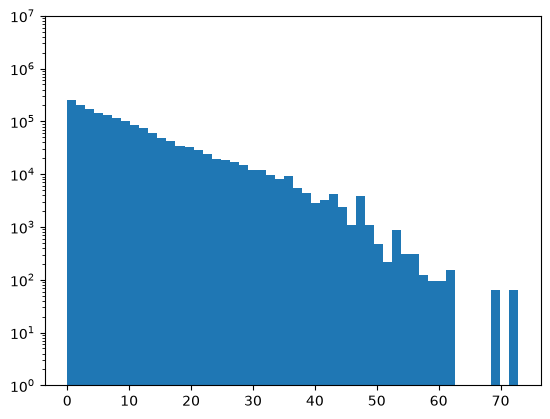

In [ ]:
fig, ax = plt.subplots()

ax.hist(energy_in_tiles_fd.flatten(), bins=50)
ax.set_ylim(1, 1e7)
ax.set_yscale("log")

In [ ]:
energy_in_tiles_td = omicron.get_energy_in_tiles_time_domain_data(
    whitened_time_domain_data,
    frequency_mask=frequency_mask,
    times=times,
    characteristic_frequencies=characteristic_frequencies,
    quality_factors=quality_factors,
    sampling_frequency=omicron_configuration.target_sampling_frequency,
).block_until_ready()

In [ ]:
jnp.mean(energy_in_tiles_td)

Array(0.00551077, dtype=float32)

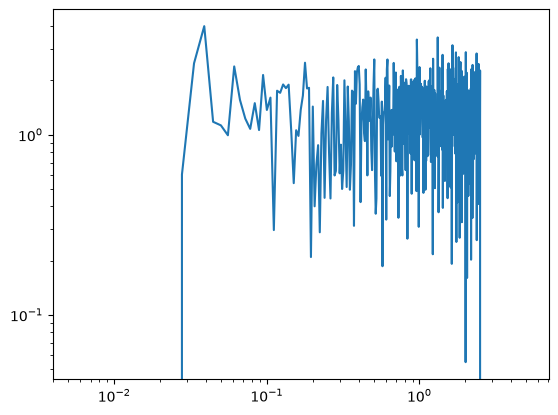

In [ ]:
fig, ax = plt.subplots()

frequencies = np.linspace(0, segment_sampling_frequency / 2, len(whitened_frequency_domain_data))
ax.loglog(frequencies, np.abs(whitened_frequency_domain_data))

In [ ]:
# maximum_energy_cluster_tiles, energy_in_tiles, passing_coordinates, cluster, (quality_factors, characteristic_frequencies, times) =  omicron.scan_segment(test_time_domain_data, omicron_configuration)

In [ ]:
# num_time_ticks = 8
# num_frequency_ticks = 8
# time_tick_indices = jnp.round(jnp.linspace(0, times.shape[0], num_time_ticks)).astype(int)
# time_ticks = [get_utc_from_gps_time(float(x)) for x in times[time_tick_indices]]
# frequency_tick_indices = jnp.round(jnp.linspace(0, characteristic_frequencies.shape[0], num_frequency_ticks)).astype(int)
# frequency_ticks = characteristic_frequencies[frequency_tick_indices]

# for ii in range(len(quality_factors)):
#     quality_factor = quality_factors[ii]
#     aspect_ratio = len(times) / len(characteristic_frequencies)
#     fig, ax = plt.subplots(figsize=(6.75, 6.75 * aspect_ratio))

#     ax.imshow(energy_in_tiles[:, :, ii].T, origin="lower", aspect = len(times) / len(characteristic_frequencies) / 2)
#     ax.set_xticks(time_tick_indices,time_ticks)
#     ax.set_yticks(frequency_tick_indices, [f"{x:0.4f}" for x in jnp.round(frequency_ticks, decimals=5)])
#     ax.text(len(times) * 0.8, len(characteristic_frequencies) * 0.8, f"Q={quality_factor:0.2f}", bbox={"facecolor":"white", "alpha":0.9})
#     ax.set_xlim(0, len(times))
#     ax.set_ylim(0, len(characteristic_frequencies))
#     ax.set_xlabel("Tile Time [s]")
#     ax.set_ylabel("Tile Frequency [Hz]")


#     fig.savefig(f"omicron_test_images/test_omicron_q={quality_factor:0.2f}.pdf", bbox_inches="tight")

#     plt.clf()

# print("Finished plotting q-scans")

# fig, ax = plt.subplots()

# scatter = ax.scatter(passing_coordinates[:, 0] - times[0], passing_coordinates[:, 1], c=cluster.labels_)
# ax.set_xticklabels(time_ticks)
# ax.set_xlabel("Tile Time [s]")
# ax.set_ylabel("Tile Frequency [Hz]")
# ax.legend(*scatter.legend_elements(), loc="upper right", title="Cluster Index")
# ax.set_yscale("log")

# fig.savefig("omicron_test_images/clustered_result.pdf", bbox_inches="tight")

# print(f"Completed all plotting")


In [ ]:
def frequency_domain_omicron_windows(
    frequency_array: jnp.ndarray,
    characteristic_frequencies: jnp.ndarray,
    quality_factors: jnp.ndarray,
) -> jnp.ndarray:
    """The Omicron bi-square windows for a set of characteristic frequencies and quality factors

    Parameters
    ==========
        frequency_array : jnp.ndarray
            The array of frequencies over which to compute the window. Shape (M,)
        characteristic_frequencies : jnp.ndarray
            The characteristic frequencies of the windows ($\\phi$ in Robinet). Shape (N,)
        quality_factor : jnp.ndarray
            The quality factors for the windows. Shape (O,)

    Returns
    =======
        windows : jnp.ndarray
            Shape (M, N, O)
    """
    # Robinet technical document equations 8-13
    # Note shift to characteristic frequency here instead of shifting data
    # Dimensions len(frequency_array) x len(characteristic_frequencies) x len(quality_factors)

    # Shape (N, O)
    window_halfwidths = (
        jnp.sqrt(11) * characteristic_frequencies[:, None] / quality_factors[None, :]
    )
    # Shape (N, O)
    normalization_factors = jnp.sqrt(315 / 128 / window_halfwidths)
    # Shape (M, N, O)
    kernels = normalization_factors[None, :, :] * (
        1 - ((frequency_array[:, None, None] - characteristic_frequencies[None, :, None])/window_halfwidths[None, :, :]) ** 2 
    ) ** 2
    # Shape (M, N, O)
    windows = jnp.where(
        jnp.abs(
            frequency_array[:, None, None] - characteristic_frequencies[None, :, None]
        )
        < window_halfwidths[None, :, :],
        kernels,
        0,
    )
    return windows


In [ ]:
duration =10000
sampling_frequency = 100


number_samples = int(duration * sampling_frequency)
times = np.linspace(0, duration, number_samples)
characteristic_frequencies = jnp.array([5, 10, 20, 25])
quality_factors = jnp.array([np.sqrt(11), 5, 6, 7])
frequencies = jnp.linspace(0, sampling_frequency/2, int(duration*sampling_frequency) // 2 + 1)
window_halfwidths = (
    jnp.sqrt(11) * characteristic_frequencies[:, None] / quality_factors[None, :]
)
# test_fft_data_td = jax.random.normal(rng_key, (number_samples,))
# test_ffd_data_fd_from_rfft = jnp.fft.rfft(test_fft_data_td)
# test_fft_data_td

In [ ]:
window_halfwidths

Array([[ 5.       ,  3.3166249,  2.763854 ,  2.3690178],
       [10.       ,  6.6332498,  5.527708 ,  4.7380357],
       [20.       , 13.2664995, 11.055416 ,  9.476071 ],
       [25.       , 16.583124 , 13.81927  , 11.845089 ]], dtype=float32)

In [ ]:
windows = frequency_domain_omicron_windows(
    frequencies,
    characteristic_frequencies,
    quality_factors
)

In [ ]:
jnp.sum(jnp.abs(windows) ** 2, axis=0) / duration

Array([[2.       , 2.0000002, 2.0000002, 1.9999998],
       [2.0000002, 2.0000002, 2.0000002, 2.0000002],
       [1.9999998, 2.0000002, 2.0000002, 1.9999998],
       [2.0000002, 2.0000002, 2.0000002, 2.0000002]], dtype=float32)

In [ ]:
def whiten_timeseries(
    time_domain_data,
    sampling_frequency,
    duration,
    tukey_alpha=0.2,
    number_welch_segments=16,
    minimum_frequency=None,
    maximum_frequency=None,
):


    tukey_window = get_window(("tukey", tukey_alpha), len(time_domain_data))

    windowed_time_domain_data = detrend(time_domain_data) * tukey_window
    # windowed_time_domain_data = time_domain_data * tukey_window
    window_factor = jnp.mean(tukey_window ** 2)
    window_scale = jnp.sqrt(window_factor)

    number_samples = len(windowed_time_domain_data)
    frequencies = jnp.linspace(0, sampling_frequency / 2, number_samples // 2 + 1)
    frequency_domain_data = jnp.fft.rfft(windowed_time_domain_data) / sampling_frequency

    psd_frequencies, psd = welch(
        time_domain_data,
        fs=sampling_frequency,
        average="mean",
        window=("tukey", tukey_alpha),
        nperseg=int(sampling_frequency * duration / number_welch_segments),
        noverlap=0,
    )
    interpolated_psd = jnp.interp(frequencies, psd_frequencies, psd)

    if minimum_frequency is not None and maximum_frequency is not None:
        frequency_mask = (frequencies > minimum_frequency) & (
            frequencies < maximum_frequency
        )
    elif minimum_frequency is not None:
        frequency_mask = frequencies > minimum_frequency
    elif maximum_frequency is not None:
        frequency_mask = frequencies < maximum_frequency
    else:
        frequency_mask = jnp.ones(frequencies.shape).astype(bool)
    mask_factor = jnp.mean(frequency_mask)

    frequency_domain_data_whitened = (
        frequency_domain_data * frequency_mask / (0.5 * jnp.sqrt(duration)) / jnp.sqrt(interpolated_psd) / window_scale
    )


    time_domain_data_whitened = (
        jnp.fft.irfft(frequency_domain_data_whitened) * jnp.sum(frequency_mask) ** 0.5 / mask_factor
    )
    return time_domain_data_whitened, frequency_domain_data_whitened, frequency_mask, interpolated_psd

In [ ]:
# frequency_domain_data

In [ ]:
# 